# 🧠 K-Means Clustering 예제 (Scikit-learn)

## 📌 개요
- K-Means는 대표적인 비지도 학습 (Unsupervised Learning)
- 데이터를 K개의 그룹으로 자동 분류

---

## 🔥 핵심 아이디어

```text id="kmeans_core"
1. 중심점(k)을 랜덤으로 선택
2. 각 데이터 → 가장 가까운 중심에 할당
3. 중심점 재계산
4. 반복 (수렴할 때까지)

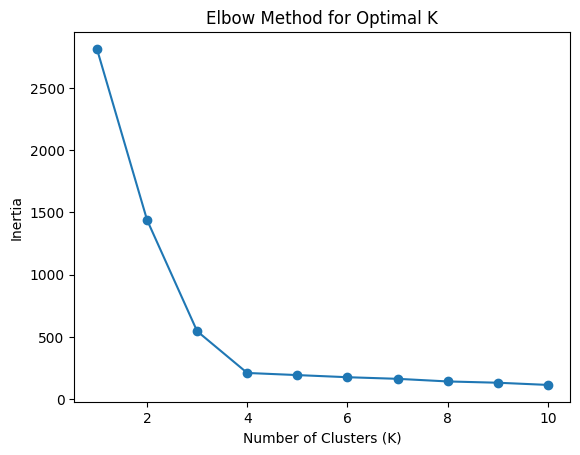

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1️⃣ 데이터 생성
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

# 2️⃣ K 값 범위 설정
k_range = range(1, 11)

inertias = []

# 3️⃣ 각 K에 대해 KMeans 학습
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)  # 응집도 저장

# 4️⃣ Elbow 그래프 시각화
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

# 🧠 결과 해석 방법
# ✔ 그래프 모양
# inertia ↓ 급감 → 완만해지는 지점
# ✔ Elbow (팔꿈치) 위치
# 꺾이는 지점 = 최적 K
# 💥 예시 해석
# K = 1 → 매우 큼 (나쁨)
# K = 2 → 많이 감소
# K = 3 → 감소
# K = 4 → 감소폭 줄어듦 ← ✔ 최적
# K = 5~10 → 거의 변화 없음
# 🔥 핵심 직관
# K 늘리면 → 더 잘 맞음 (inertia 감소)
# 하지만 어느 순간 → 효과 거의 없음
# 🧠 Inertia 의미
# 클러스터 내부 데이터 거리 합
# → 작을수록 좋은 군집
# 🎯 Elbow Method 핵심
# "설명력 증가가 급격히 줄어드는 지점이 최적 K"
# 🚀 한 줄 핵심

# 👉 "Elbow Method는 K를 늘렸을 때 개선 효과가 급격히 줄어드는 지점을 찾는 방법이다"

🔥 자동 선택된 최적 K: 4


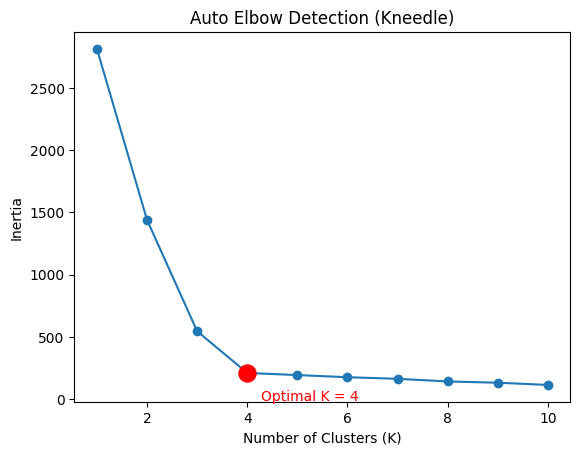

In [2]:
%pip install kneed
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from kneed import KneeLocator

# 1️⃣ 데이터 생성
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

# 2️⃣ K 범위
k_range = range(1, 11)
inertias = []

# 3️⃣ KMeans 실행
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

#"Kneedle 알고리즘은 inertia 곡선의 꺾이는 지점을 자동으로 찾아 K를 결정한다"
# ✔ 핵심 원리
# 곡선에서 "급격히 꺾이는 지점" 찾기
# ✔ 수학적 느낌
# K 증가 → inertia 감소
# 감소율이 급격히 줄어드는 지점 탐색
#곡률 변화가 최대인 지점 = elbow

# 4️⃣ 🔥 Elbow 자동 탐지 (핵심)
knee = KneeLocator(
    k_range,
    inertias,
    curve="convex",
    direction="decreasing"
)

optimal_k = knee.knee
optimal_inertia = inertias[optimal_k - 1]

print("🔥 자동 선택된 최적 K:", optimal_k)

# 5️⃣ 시각화
plt.plot(k_range, inertias, marker='o')

# 🔴 최적 K 강조
plt.scatter(optimal_k, optimal_inertia, color='red', s=150, zorder=5)

plt.annotate(
    f"Optimal K = {optimal_k}",
    (optimal_k, optimal_inertia),
    textcoords="offset points",
    xytext=(10, -20),
    color='red'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Auto Elbow Detection (Kneedle)")
plt.show()